# EAZY Performance Analysis

<p>The following code performs an analysis of the EAZY photometric redshift performanced with the following functions:</p>

- Comparsion with MSAEXP spectroscopic redshift
- Visualisation of select SEDs (WIP)
- Image retrieval for select targets (WIP)

#### zspec Performance Plot

σ_NMAD = 0.1004, Outlier fraction = 37.36%


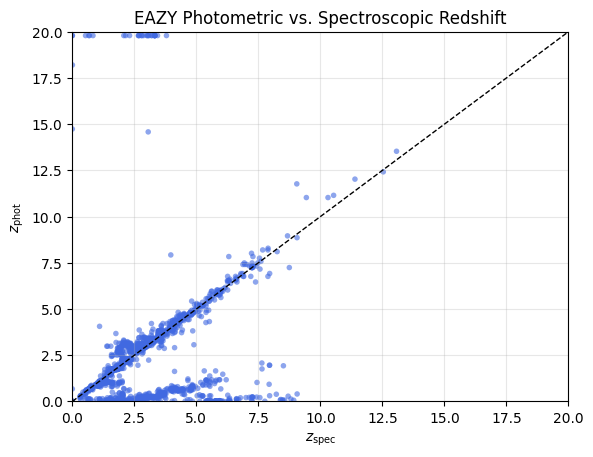

In [472]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table


def plot_zphot_zspec(zout_path, zmax=6, outlier_thresh=0.15,
                     ax=None, highlight_id=None):

    zout = Table.read(zout_path, format='ascii')

    colnames = [c.lower() for c in zout.colnames]
    zspec_col = zout.colnames[colnames.index('z_spec')] if 'z_spec' in colnames else zout.colnames[colnames.index('zspec')]
    zphot_col = zout.colnames[colnames.index('z_a')] if 'z_a' in colnames else zout.colnames[colnames.index('z_phot')]

    zspec = np.array(zout[zspec_col])
    zphot = np.array(zout[zphot_col])

    mask = (zspec >= 0) & (zphot >= 0)
    zspec, zphot = zspec[mask], zphot[mask]

    dz = (zphot - zspec) / (1 + zspec)
    dz = dz[np.isfinite(dz)]

    sigma_nmad = 1.48 * np.median(np.abs(dz - np.median(dz)))
    outlier_frac = np.mean(np.abs(dz) > outlier_thresh)

    if ax is None:
        fig, ax = plt.subplots()

    ax.scatter(zspec, zphot, s=16, alpha=0.6,
               color='royalblue', edgecolor='none')

    ax.plot([0, zmax], [0, zmax], 'k--', lw=1)

    # Highlight
    if highlight_id is not None and 'id' in zout.colnames:
        id_array = np.array(zout['id'])[mask]
        match = id_array == highlight_id

        if np.any(match):
            ax.scatter(zspec[match], zphot[match],
                       s=100, facecolor='none',
                       edgecolor='red', linewidth=2)

    ax.set_xlabel(r'$z_{\rm spec}$')
    ax.set_ylabel(r'$z_{\rm phot}$')
    ax.set_xlim(0, zmax)
    ax.set_ylim(0, zmax)
    ax.grid(alpha=0.3)

    # txt = (rf"$\sigma_{{\rm NMAD}} = {sigma_nmad:.3f}$" + "\n" +
    #        rf"Outlier frac = {outlier_frac*100:.1f}%")

    # ax.text(0.05*zmax, 0.9*zmax, txt,
    #         fontsize=11,
    #         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    ax.set_title('EAZY Photometric vs. Spectroscopic Redshift')

    print(f"σ_NMAD = {sigma_nmad:.4f}, Outlier fraction = {outlier_frac*100:.2f}%")

plot_zphot_zspec('../inputs/OUTPUT/photz.zout', zmax=20)

#Delete the comment on line 1 and delete last line (incomplete)

In [152]:
RUN_NAME = 'GOODS-S'

cat_path = f'../inputs/{RUN_NAME}_photometry.cat'
cat = Table.read(cat_path, format='ascii')

cat

id,f_nircam_f090w,e_nircam_f090w,f_wfc3-ir_f105w,e_wfc3-ir_f105w,f_wfc3-ir_f110w,e_wfc3-ir_f110w,f_nircam_f115w,e_nircam_f115w,f_niriss_f115w,e_niriss_f115w,f_wfc3-ir_f125w,e_wfc3-ir_f125w,f_wfc3-ir_f140w,e_wfc3-ir_f140w,f_nircam_f150w,e_nircam_f150w,f_niriss_f150w,e_niriss_f150w,f_wfc3-ir_f160w,e_wfc3-ir_f160w,f_nircam_f182m,e_nircam_f182m,f_nircam_f200w,e_nircam_f200w,f_niriss_f200w,e_niriss_f200w,f_nircam_f210m,e_nircam_f210m,f_nircam_f277w,e_nircam_f277w,f_nircam_f335m,e_nircam_f335m,f_wfc3-uvis_f350lp,e_wfc3-uvis_f350lp,f_nircam_f356w,e_nircam_f356w,f_nircam_f410m,e_nircam_f410m,f_nircam_f430m,e_nircam_f430m,f_acs_f435w,e_acs_f435w,f_nircam_f444w,e_nircam_f444w,f_nircam_f460m,e_nircam_f460m,f_acs_f475w,e_acs_f475w,f_nircam_f480m,e_nircam_f480m,f_acs_f606w,e_acs_f606w,f_wfc3-uvis_f606w,e_wfc3-uvis_f606w,f_acs_f775w,e_acs_f775w,f_acs_f814w,e_acs_f814w,f_wfc3-uvis_f814w,e_wfc3-uvis_f814w,f_acs_f850lp,e_acs_f850lp,f_wfc3-uvis_f850lp,e_wfc3-uvis_f850lp,z_spec
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
51,-99.0,10000000000.0,0.0593475,0.007747864,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.05836483,0.005813961,0.07454174,0.01529728,-99.0,10000000000.0,-99.0,10000000000.0,0.07680882,0.008678746,0.155576,0.004910302,-99.0,10000000000.0,-99.0,10000000000.0,0.1186988,0.005949958,-99.0,10000000000.0,-99.0,10000000000.0,0.04048118,0.003438643,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.02121764,0.003075538,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.05556428,0.001915305,-99.0,10000000000.0,0.057534,0.004491354,0.0670911,0.001731345,-99.0,10000000000.0,0.06828083,0.004686326,-99.0,10000000000.0,2.8997
70,-99.0,10000000000.0,0.01354786,0.007710654,0.01639714,0.004596723,-99.0,10000000000.0,-99.0,10000000000.0,0.02268065,0.004125744,0.03173412,0.01544646,-99.0,10000000000.0,-99.0,10000000000.0,0.02316182,0.005106059,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.0194116,0.002879063,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.01309401,0.001772172,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.02514552,0.002325826,-99.0,10000000000.0,0.02807122,0.005344385,0.0318174,0.001566007,-99.0,10000000000.0,0.02745068,0.004666157,-99.0,10000000000.0,3.0992
161,-99.0,10000000000.0,0.04325883,0.007784499,0.04980086,0.004766304,-99.0,10000000000.0,-99.0,10000000000.0,0.05633038,0.004780914,0.06612275,0.01557286,-99.0,10000000000.0,-99.0,10000000000.0,0.1200044,0.006138493,0.2241059,0.003756392,-99.0,10000000000.0,-99.0,10000000000.0,0.2438887,0.004796057,-99.0,10000000000.0,-99.0,10000000000.0,0.01667261,0.003198988,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.008990909,0.001841468,0.5182109,0.00537357,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.01992272,0.001908054,-99.0,10000000000.0,0.0264787,0.00460572,0.03409667,0.001679477,-99.0,10000000000.0,0.0365191,0.004624361,-99.0,10000000000.0,2.701
162,-99.0,10000000000.0,0.2544747,0.008272586,0.2781704,0.004947456,-99.0,10000000000.0,-99.0,10000000000.0,0.3152914,0.004981153,0.3086511,0.01510506,-99.0,10000000000.0,-99.0,10000000000.0,0.4888257,0.00622609,0.4535697,0.003849984,-99.0,10000000000.0,-99.0,10000000000.0,0.7043064,0.00513045,-99.0,10000000000.0,-99.0,10000000000.0,0.1977301,0.003311004,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.1427426,0.002009383,0.5049547,0.0053151

In [153]:
zout_path = '../inputs/OUTPUT/photz.zout'
zout = Table.read(zout_path, format='ascii')
zout

id,z_spec,z_a,z_m1,chi_a,l68,u68,l95,u95,l99,u99,nfilt,q_z,z_peak,peak_prob,z_mc
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64
51,2.8997,3.493,3.535,43.03912,3.437,3.655,3.393,3.723,3.383,3.747,12,1.76119,3.5343,0.999,3.5048
70,3.0992,0.445,1.583,18.02155,0.358,3.358,0.191,3.494,0.101,3.606,11,1059070000.0,0.4442,0.601,0.2833
161,2.701,3.108,3.102,9.225253,3.025,3.187,2.901,3.24,2.826,3.292,14,0.390721,3.1023,0.999,3.1467
162,2.3445,3.108,3.119,292.6653,3.064,3.167,3.05,3.204,3.04,3.211,14,4.55549,3.1139,0.87,3.1211
168,4.0408,4.216,4.188,61.28473,4.105,4.272,4.0,4.292,3.937,4.321,14,2.25445,4.1875,0.997,4.2586
170,4.8214,4.936,4.947,18.65328,4.85,5.055,4.734,5.137,4.63,5.23,12,1.24302,4.9467,0.998,4.9316
183,1.9627,2.503,2.281,16.82446,1.84,2.591,1.685,2.68,1.617,2.767,12,2.17503,2.5392,0.619,2.5242
191,2.9193,3.448,3.454,34.65374,3.396,3.51,3.365,3.556,3.249,3.605,12,1.37387,3.4545,0.997,3.4077
194,3.5979,3.914,3.908,64.08363,3.827,3.984,3.781,4.075,3.725,4.134,14,2.37795,3.906,0.988,3.9382


In [338]:
diagnostic_tab = zout['id', 'z_spec', 'z_a']
diagnostic_tab['delta_z'] = np.abs((zout['z_a'] - zout['z_spec'])) / (1 + zout['z_spec'])
len_diagnostic = len(diagnostic_tab) # Account for mismatch from EAZY termination issue - FIX IF POSSIBLE

for col_name in cat.colnames:
    if col_name.startswith('f_'):
        diagnostic_tab[col_name] = cat[col_name][0:len_diagnostic]
    if col_name.startswith('e_'):
        diagnostic_tab[col_name] = cat[col_name][0:len_diagnostic]

diagnostic_tab.sort('delta_z', reverse=True)

diagnostic_tab[:10]

id,z_spec,z_a,delta_z,f_nircam_f090w,e_nircam_f090w,f_wfc3-ir_f105w,e_wfc3-ir_f105w,f_wfc3-ir_f110w,e_wfc3-ir_f110w,f_nircam_f115w,e_nircam_f115w,f_niriss_f115w,e_niriss_f115w,f_wfc3-ir_f125w,e_wfc3-ir_f125w,f_wfc3-ir_f140w,e_wfc3-ir_f140w,f_nircam_f150w,e_nircam_f150w,f_niriss_f150w,e_niriss_f150w,f_wfc3-ir_f160w,e_wfc3-ir_f160w,f_nircam_f182m,e_nircam_f182m,f_nircam_f200w,e_nircam_f200w,f_niriss_f200w,e_niriss_f200w,f_nircam_f210m,e_nircam_f210m,f_nircam_f277w,e_nircam_f277w,f_nircam_f335m,e_nircam_f335m,f_wfc3-uvis_f350lp,e_wfc3-uvis_f350lp,f_nircam_f356w,e_nircam_f356w,f_nircam_f410m,e_nircam_f410m,f_nircam_f430m,e_nircam_f430m,f_acs_f435w,e_acs_f435w,f_nircam_f444w,e_nircam_f444w,f_nircam_f460m,e_nircam_f460m,f_acs_f475w,e_acs_f475w,f_nircam_f480m,e_nircam_f480m,f_acs_f606w,e_acs_f606w,f_wfc3-uvis_f606w,e_wfc3-uvis_f606w,f_acs_f775w,e_acs_f775w,f_acs_f814w,e_acs_f814w,f_wfc3-uvis_f814w,e_wfc3-uvis_f814w,f_acs_f850lp,e_acs_f850lp,f_wfc3-uvis_f850lp,e_wfc3-uvis_f850lp
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
20308,0.0,19.798,19.798,0.1097986,0.001542258,0.2147603,0.003303366,-99.0,10000000000.0,0.339103,0.001599689,-99.0,10000000000.0,0.2581867,0.003571684,0.2184738,0.01501604,0.3395641,0.001706745,-99.0,10000000000.0,0.2195176,0.004165937,0.307249,0.00323382,0.3155098,0.001548585,-99.0,10000000000.0,0.3264672,0.004018571,0.1812038,0.001166758,0.1816753,0.001319971,0.02133232,0.001649957,0.1914341,0.001159679,0.1752464,0.001513529,-99.0,10000000000.0,0.003212092,0.002155546,0.1400203,0.001263013,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.003774585,0.002359408,-99.0,10000000000.0,0.04328797,0.004909961,0.07753968,0.002108828,-99.0,10000000000.0,0.1500409,0.005470751,-99.0,10000000000.0
15688,0.0004,19.798,19.78968412634946,0.2248556,0.001498959,0.4460113,0.002640266,-99.0,10000000000.0,0.6569699,0.0019234,-99.0,10000000000.0,0.598217,0.003615097,0.5932999,0.01850337,0.8843298,0.00221169,-99.0,10000000000.0,0.6096324,0.004410355,0.8316229,0.003382258,0.8962303,0.002228399,-99.0,10000000000.0,0.9353584,0.00390155,0.5642621,0.001726706,0.5852344,0.00183247,0.02624472,0.001757729,0.6109408,0.001804866,0.5955784,0.001876095,-99.0,10000000000.0,-8.805982e-05,0.0006553328,0.4743215,0.001645945,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.004114657,0.000472902,-99.0,10000000000.0,0.05614733,0.0007641155,0.09662413,0.001567106,-99.0,10000000000.0,0.2044195,0.001379138,-99.0,10000000000.0
19929,0.0033,18.206,18.142828665404164,0.002583576,0.001020817,-0.0006667693,0.00288886,-99.0,10000000000.0,0.01331462,0.000655525,-99.0,10000000000.0,0.002869216,0.003001508,0.002458805,0.005553499,0.006179712,0.000681862,-99.0,10000000000.0,0.000816076,0.003736126,0.009617991,0.002538166,0.004687222,0.0006726498,-99.0,10000000000.0,0.009737009,0.003176386,0.002206694,0.0004226571,0.0003267688,0.0006776284,0.00260794,0.001972606,0.01002568,0.0005081444,0.0383057,0.0008479478,-99.0,10000000000.0,0.0005706323,0.0006737372,0.02973255,0.0007039175,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,5.310493e-05,0.0004493739,-99.0,10000000000.0,-3.986077e-05,0.0005461133,-0.001889109,0.001409717,-99.0,10000000000.0,0.000142832,0.0009185891,-99.0,10000000000.0
34611,0.0,14.741,14.741,-99.0,10000000000.0,0.3164451,0.003376646,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,0.5668931,0.003853668,0.551225,0.01436865,-99.0,10000000000.0,-99.0,10000000000.0,0.3786429,0.004381292,0.2417962,0.003117496,-99.0,1000000

In [339]:
from pathlib import Path

# Match pivot to DAWN filter name

def pivot_wavelength(wave, throughput):
    """
    Compute pivot wavelength.
    
    Parameters
    ----------
    wave : array
        Wavelength array (same units throughout, e.g. Angstrom or micron)
    throughput : array
        Dimensionless system throughput
    
    Returns
    -------
    lambda_pivot : float
        Pivot wavelength in same units as `wave`
    """
    num = np.trapz(wave * throughput, wave)
    den = np.trapz(throughput / wave, wave)
    return np.sqrt(num / den)

# Step 1 - Identify pivot wavelengths for each filter
filter_dirs = {
    "nircam": Path("../throughputs/nircam_throughputs"),
    "niriss": Path("../throughputs/niriss_throughputs"),
    "wfc3-ir":   Path("../throughputs/wfc3-ir_throughputs"),
    "wfc3-uvis": Path("../throughputs/wfc3-uvis_throughputs"),
    "acs":    Path("../throughputs/acs_throughputs"),
}

pivot_dict = {}

import re

filter_cat = []
for col in diagnostic_tab.colnames:
    if col.startswith("f_"):
        # Extract filter name using regex (e.g., f_nircam_f150w → nircam_f150w)
        match = re.match(r"f_(.+)", col)
        if match:
            filter_cat.append(match.group(1))

n_files_found = 0

for filt in filter_cat:
    instrument, filter = filt.split("_")  # Get instrument prefix (e.g., nircam)
    for file in filter_dirs[instrument].glob("*.txt"):
        if file.name.lower().endswith(f"{filter}.txt"):
            data = np.genfromtxt(file, names=None, dtype=float, invalid_raise=False)
            wave = data[:, 0]  # Wavelength
            throughput = data[:, 1]  # Throughput
            if "nircam" in instrument:
                lambda_pivot = pivot_wavelength(wave, throughput) * 10000  # Convert from micron to Angstrom
            elif "niriss" in instrument:
                wave = data[:, 0][1:]  # Wavelength (skip first row which is header)
                throughput = (data[:, 1] * data[:, 2])[1:] # Throughput - deal with unlabeled headers
                lambda_pivot = pivot_wavelength(wave, throughput) * 10000  # Convert from micron to Angstrom
            else:
                lambda_pivot = pivot_wavelength(wave, throughput)
            pivot_dict[filt] = lambda_pivot
            n_files_found += 1

print(n_files_found, "files found and processed.")
pivot_dict

32 files found and processed.


{'nircam_f090w': 9024.004322715571,
 'wfc3-ir_f105w': 10551.04690691064,
 'wfc3-ir_f110w': 11534.458556471893,
 'nircam_f115w': 11540.782060233896,
 'niriss_f115w': 11569.245393753137,
 'wfc3-ir_f125w': 12486.059786098389,
 'wfc3-ir_f140w': 13922.907351513846,
 'nircam_f150w': 15008.986492444132,
 'niriss_f150w': 14931.4452332518,
 'wfc3-ir_f160w': 15369.175706752383,
 'nircam_f182m': 18452.162232046972,
 'nircam_f200w': 19876.00630661438,
 'niriss_f200w': 19859.329259459253,
 'nircam_f210m': 20955.94879405288,
 'nircam_f277w': 27762.299040374513,
 'nircam_f335m': 33622.534099039454,
 'wfc3-uvis_f350lp': 5873.870009138059,
 'nircam_f356w': 35654.89020001737,
 'nircam_f410m': 40829.88273666917,
 'nircam_f430m': 42812.95459815133,
 'acs_f435w': 4329.846864295937,
 'nircam_f444w': 44017.43343383445,
 'nircam_f460m': 46296.16879154382,
 'acs_f475w': 4746.939804554965,
 'nircam_f480m': 48165.46417311176,
 'acs_f606w': 5921.883734588944,
 'wfc3-uvis_f606w': 5889.165748864213,
 'acs_f775w': 7

#### Test 1 - SED Visualization

In [ ]:
def diagnostic_plot(target, table, pivot_dict):

    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    # ---------------------
    # Left panel: SED
    # ---------------------
    ax_sed = axes[0]

    wavelengths = []
    fluxes = []
    errs = []
    filters = []

    for col in table.colnames:
        if col.startswith("f_"):
            flux = target[col]
            if flux > 0:
                filters.append(col)
                filt = col.replace("f_", "")
                err_col = f"e_{filt}"
                if filt in pivot_dict:
                    wavelengths.append(pivot_dict[filt])
                    fluxes.append(flux)
                    errs.append(target[err_col])

    wavelengths = np.array(wavelengths)
    fluxes = np.array(fluxes)
    errs = np.array(errs)
    order = np.argsort(wavelengths)
    wavelengths = wavelengths[order]
    fluxes = fluxes[order]
    errs = errs[order]

    ax_sed.errorbar(
    wavelengths,
    fluxes,
    yerr=errs,
    fmt='o',
    capsize=3
    )

    ax_sed.plot(wavelengths, fluxes)

    ax_sed.set_xscale("log")
    ax_sed.set_yscale("log")
    ax_sed.set_xlabel("Wavelength (Å)")
    ax_sed.set_ylabel("Flux (μJy)")
    ax_sed.set_title(f"ID {target['id']}")

    lya = 1216 * (1 + target["z_spec"]) # 1216 angstrom rest-wavelength Lyman-alpha line
    ax_sed.axvline(lya, linestyle="--", color="green", label="Lyman Alpha")

    lybr = 912 * (1 + target["z_spec"]) # 912 angstrom rest-wavelength Lyman break
    ax_sed.axvline(lybr, linestyle="--", color="red", label="Lyman Break")
    ax_sed.legend()

    # ---------------------
    # Right panel: zphot vs zspec
    # ---------------------
    ax_z = axes[1]
    plot_zphot_zspec('../inputs/OUTPUT/photz.zout', ax=ax_z, zmax=10, highlight_id=target['id'])
    print(f"Filters: {filters}")
    print(len(filters))
    plt.tight_layout()
    plt.show()

In [413]:
highz_tab = diagnostic_tab[diagnostic_tab['z_spec'] > 6]

In [ ]:
pivot_dict['acs_f475w']

4746.939804554965

In [468]:
print(highz_tab[11]['f_acs_f475w'])

0.0009915195


Target 29416: z_spec = 6.629, z_phot = 0.010, delta_z = 0.868
σ_NMAD = 0.1004, Outlier fraction = 37.36%
Filters: ['f_nircam_f090w', 'f_wfc3-ir_f105w', 'f_nircam_f115w', 'f_niriss_f115w', 'f_wfc3-ir_f125w', 'f_wfc3-ir_f140w', 'f_nircam_f150w', 'f_niriss_f150w', 'f_wfc3-ir_f160w', 'f_nircam_f182m', 'f_nircam_f200w', 'f_niriss_f200w', 'f_nircam_f210m', 'f_nircam_f277w', 'f_nircam_f335m', 'f_nircam_f356w', 'f_nircam_f410m', 'f_nircam_f430m', 'f_nircam_f444w', 'f_nircam_f460m', 'f_acs_f475w', 'f_nircam_f480m', 'f_wfc3-uvis_f606w', 'f_acs_f814w', 'f_acs_f850lp']
25


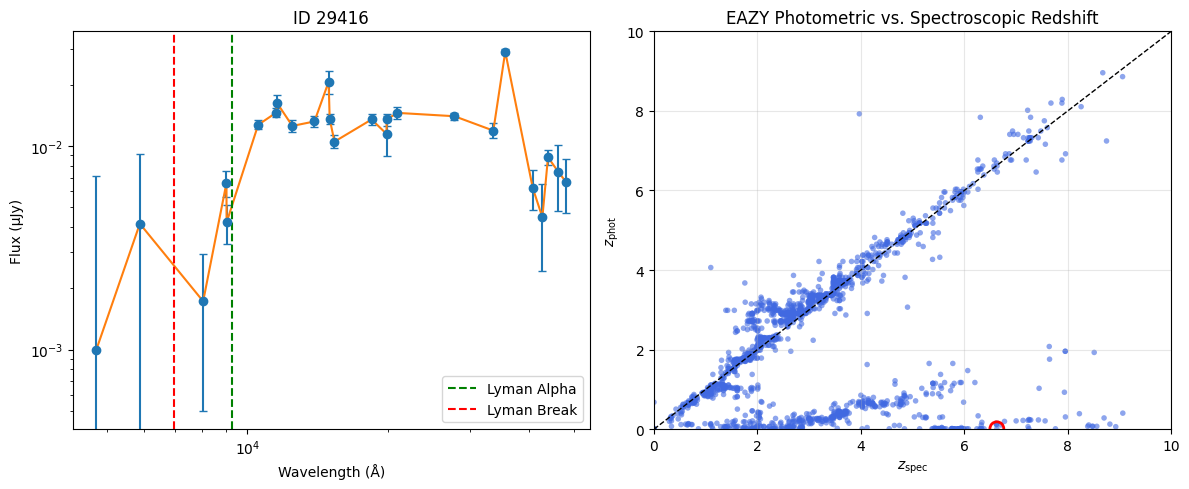

In [470]:
target = highz_tab[11]
print(f"Target {target['id']}: z_spec = {target['z_spec']:.3f}, z_phot = {target['z_a']:.3f}, delta_z = {target['delta_z']:.3f}")

diagnostic_plot(target, diagnostic_tab, pivot_dict)

# Quality cutoff at highz index 220

#### Test 2 - Some sample metrics

In [432]:
# Metrics
from curses import error

def weighted_mean(values, errors):
    weights = 1 / errors**2
    return np.sum(values * weights) / np.sum(weights), 1 / np.sum(weights)

def get_set_properties(table, pivot_dict):
    blue_missing = []
    snrs_blue = []
    snrs_red = []
    frac_errs = []
    n_reds = []
    break_strengths = []
    n_filters = []
    n_blues = []

    for target in table:
        lya_pos = 912 * (1 + target["z_spec"])

        wavelengths = []
        fluxes = []
        errors = []
        filters = []

        # Extract all data of target and sort by wavelength
        for col in table.colnames:
            if col.startswith("f_"):

                flux = target[col]
                filt = col.replace("f_", "")
                err_col = f"e_{filt}"

                if filt in pivot_dict and err_col in table.colnames:

                    err = target[err_col]

                    if flux > 0 and err > 0:
                        wavelengths.append(pivot_dict[filt])
                        fluxes.append(flux)
                        errors.append(err)
                        filters.append(filt)

        wavelengths = np.array(wavelengths)
        fluxes = np.array(fluxes)
        errors = np.array(errors)
        filters = np.array(filters)

        order = np.argsort(wavelengths)

        wavelengths = wavelengths[order]
        fluxes = fluxes[order]
        errors = errors[order]
        filters = filters[order]

        # Compute fractional error at Lyman-alpha position
        idx = np.argmin(np.abs(wavelengths - lya_pos))
        frac_errs.append(errors[idx] / fluxes[idx])
        
        # Count number of red filters
        n_reds.append(np.sum(wavelengths > lya_pos))
        n_blues.append(np.sum(wavelengths < lya_pos))
        n_filters.append(len(wavelengths))

        # Split into blue and red sides of Lyman-alpha
        blue_mask = wavelengths < lya_pos
        red_mask = wavelengths > lya_pos
        
        # If we have blue filters, compute SNRs + break strength from 2 closest filters
        if np.any(blue_mask):
            # Compute SNRs
            snrs_blue.append(np.mean(fluxes[blue_mask]/errors[blue_mask]))
            snrs_red.append(np.mean(fluxes[red_mask]/errors[red_mask]))

            # Compute break strength (difference in fluxes)
            blue_indices = np.where(blue_mask)[0][-2:]   # last 2 blue filters
            red_indices  = np.where(red_mask)[0][:2]     # first 2 red filters

            blue_flux   = fluxes[blue_indices]
            blue_err    = errors[blue_indices]
            red_flux    = fluxes[red_indices]
            red_err     = errors[red_indices]

            blue_avg, blue_uncertainty = weighted_mean(blue_flux, blue_err)
            red_avg, red_uncertainty = weighted_mean(red_flux, red_err)

            break_strengths.append((red_avg - blue_avg) / np.sqrt(blue_uncertainty + red_uncertainty))
            blue_missing.append(False)

        else:
            blue_missing.append(True)
            continue  # Skip to next target since we can't compute these metrics without blue filters


    return {"blue_missing": blue_missing, "snrs_blue": snrs_blue, "snrs_red": snrs_red, "break_strengths": break_strengths, "frac_errs": frac_errs, "n_reds": n_reds, "n_blues": n_blues, "n_filters": n_filters}

blue_missing:
  Bad targets: mean = 0.000, median = 0.000
  Good targets: mean = 0.032, median = 0.000
snrs_blue:
  Bad targets: mean = 1.399, median = 1.134
  Good targets: mean = 1.058, median = 0.995
snrs_red:
  Bad targets: mean = 11.734, median = 8.559
  Good targets: mean = 13.642, median = 8.194
break_strengths:
  Bad targets: mean = 1.509, median = 0.648
  Good targets: mean = 2.402, median = 1.422
frac_errs:
  Bad targets: mean = 3.643, median = 1.196
  Good targets: mean = 3.334, median = 1.091
n_reds:
  Bad targets: mean = 15.551, median = 17.000
  Good targets: mean = 14.903, median = 15.000
n_blues:
  Bad targets: mean = 2.490, median = 2.000
  Good targets: mean = 2.194, median = 2.000
n_filters:
  Bad targets: mean = 18.041, median = 19.000
  Good targets: mean = 17.097, median = 17.000


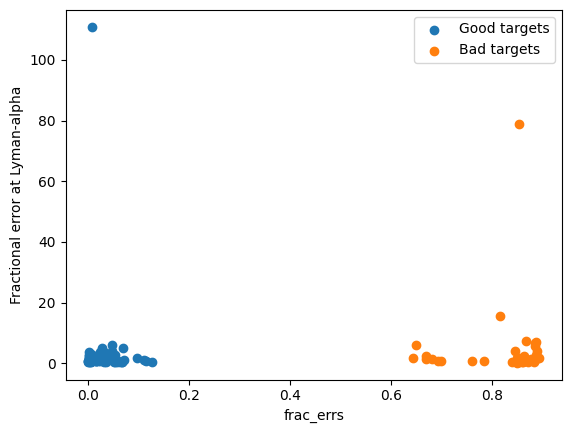

In [433]:
test_metric = "frac_errs" # Options: "snrs_blue", "snrs_red", "frac_errs", "n_reds", "break_strengths"


bad_targets = highz_tab[highz_tab['delta_z'] > 0.50]
good_targets = highz_tab[highz_tab['delta_z'] <= 0.15]

bad_metrics = get_set_properties(bad_targets, pivot_dict)
good_metrics = get_set_properties(good_targets, pivot_dict)

for metric in bad_metrics.keys():
    print(f"{metric}:")
    print(f"  Bad targets: mean = {np.mean(bad_metrics[metric]):.3f}, median = {np.median(bad_metrics[metric]):.3f}")
    print(f"  Good targets: mean = {np.mean(good_metrics[metric]):.3f}, median = {np.median(good_metrics[metric]):.3f}")


plt.figure()
if test_metric in ["snrs_blue", "snrs_red", "break_strengths"]:
    plt.scatter(good_targets['delta_z'][~np.array(good_metrics['blue_missing'])], good_metrics[test_metric], label="Good targets", color='blue')
    plt.scatter(bad_targets['delta_z'][~np.array(bad_metrics['blue_missing'])], bad_metrics[test_metric], label="Bad targets", color='red')
else:
    plt.scatter(good_targets['delta_z'], good_metrics[test_metric], label="Good targets")
    plt.scatter(bad_targets['delta_z'], bad_metrics[test_metric], label="Bad targets")
plt.xlabel(test_metric)
plt.ylabel("Fractional error at Lyman-alpha")
plt.legend()
plt.show()

#### Test 3 - photz.pz Plotting

In [477]:
# Z_MIN                0.010              # Minimum redshift
# Z_MAX                20.000             # Maximum redshift
# Z_STEP               0.010              # Redshift step size

zmin = 0.010
zmax = 20.000
dz   = 0.010

zgrid = np.arange(zmin, zmax + dz, dz)
NZ = len(zgrid)
NOBJ = len(zout)

pz_flat = np.fromfile("../inputs/OUTPUT/photz.pz", dtype=np.float64)

print("Length of pz_flat:", len(pz_flat))
print(NOBJ, NZ, NOBJ * NZ)

# NZ = len(pz_flat) // NOBJ
# pz = pz_flat.reshape((NOBJ, NZ))

Length of pz_flat: 540461
1772 2000 3544000


In [450]:
import os

size_bytes = os.path.getsize("../inputs/OUTPUT/photz.pz")
print(size_bytes / 4)

1088512.0


In [454]:
Nz = int((zmax - zmin)/dz)
N_written = len(pz_flat) // Nz
print(N_written)

print(Nz)

544
1998


In [485]:
lowest_nircam = 0
lowest_nircam_name = ""

for key in pivot_dict.keys():
    if 'nircam' in key:
        if pivot_dict[key] < lowest_nircam or lowest_nircam == 0:
            lowest_nircam = pivot_dict[key]
            lowest_nircam_name = key

for key in pivot_dict.keys():
    if 'acs' in key or 'wfc3' in key:
        if pivot_dict[key] > lowest_nircam:
            print(f"HST filter {key} exceeds lowest NIRCam pivot wavelength ({pivot_dict[key]:.1f} Å > {lowest_nircam:.1f} Å)")

HST filter wfc3-ir_f105w exceeds lowest NIRCam pivot wavelength (10551.0 Å > 9024.0 Å)
HST filter wfc3-ir_f110w exceeds lowest NIRCam pivot wavelength (11534.5 Å > 9024.0 Å)
HST filter wfc3-ir_f125w exceeds lowest NIRCam pivot wavelength (12486.1 Å > 9024.0 Å)
HST filter wfc3-ir_f140w exceeds lowest NIRCam pivot wavelength (13922.9 Å > 9024.0 Å)
HST filter wfc3-ir_f160w exceeds lowest NIRCam pivot wavelength (15369.2 Å > 9024.0 Å)
HST filter acs_f850lp exceeds lowest NIRCam pivot wavelength (9031.5 Å > 9024.0 Å)
HST filter wfc3-uvis_f850lp exceeds lowest NIRCam pivot wavelength (9176.1 Å > 9024.0 Å)
